# LBM Lid-Driven Cavity Simulation Assessment
**File:** `analysis.ipynb`  
**Author:** Marcel Wilanowicz  
**Date:** 2026-05-27  

---

### Description:
This notebook provides a comprehensive assessment of the Lattice Boltzmann Method (LBM) simulation for the Lid-Driven Cavity problem. It consists of two main stages:


1. **Physical Validation:** Comparison of normalized centerline velocity profiles ($u_x, u_y$) against the established benchmark data by Ghia et al. (1982).

2. **Parallel Verification:** A spatial node-by-node identity check between the sequential and MPI parallel versions to ensure bitwise reproducibility and correct domain decomposition.

## 1. Physical Validation: Comparison with Ghia et al. (1982)

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import os

# Config
H = 100
W = 100
U_LID = 0.1

In [36]:
# Results for u-velocity along Vertical Line through Geometric Center of Cavity 
# [Ghia et al. p.398, Table I]
ghia_y =  [0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531, 
           0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]

ghia_ux = [0.00000, -0.03717, -0.04192, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090, 
           -0.20581, -0.14098, -0.01447, 0.17527, 0.55892, 0.61756, 0.68439, 0.75837, 1.00000]

# Results for u-velocity along Vertical Line through Geometric Center of Cavity 
#[Ghia et al. p.399, Table II]
ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344, 0.5000, 
          0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]

ghia_uy = [0.00000, 0.09233, 0.10091, 0.10890, 0.12317, 0.16077, 0.17507, 0.17527, 
           0.05454, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000]


In [37]:
def get_output_by_suffix(suffix=""):
    """
    Finds the first file matching the suffix and extracts its step number.
    """
    # List all files in the outputs directory
    all_files = os.listdir("../outputs")

    # Find the file that contains your suffix and ends with .csv
    for file_name in all_files:
        if suffix == "":
                continue
        
        if suffix in file_name and file_name.endswith(".csv"):
            # Extract digits from the filename using regular expression
            match = re.search(r'output_(\d+)', file_name)
            if match:
                step = int(match.group(1))
                full_path = f"../outputs/{file_name}"
                return full_path, step

    print(f"Error: No file found with suffix '{suffix}'")
    return None, None

In [38]:
def validate(suffix=""):
    target_file, step = get_output_by_suffix(suffix=suffix)

    if not target_file:
        print("Error: Not found any files in 'outputs' directory.")
        return
    
    print(f"Loading data from: {target_file} (Step: {step})")
        
    data = pd.read_csv(target_file)

    # Centerline grid coordinates
    mid_x = (W - 1) // 2
    mid_y = (H - 1) // 2

    # Extracting vertical profile for ux comparison
    v_line = data[data['x'] == mid_x].sort_values('y')

    # Extracting horizontal profile for uy comparison
    h_line = data[data['y'] == mid_y].sort_values('x')

    # Normalizing the data (velocity profiles and dimension of the grid): 
    # we want dimensionless values for correct benchmark [Chen & Doolen, 1998, p.342].
    ux_norm = v_line['ux'] / U_LID
    y_norm = v_line['y'] / (H - 1)
    uy_norm = h_line['uy'] / U_LID
    x_norm = h_line['x'] / (W - 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # ------------ 1. Plotting vertical profile: ux(y) ------------

    # Simulation data
    ax1.plot(ux_norm, y_norm, 'b-', label='LBM Simulation Data', linewidth=2)

    # Ghia data
    ax1.plot(ghia_ux, ghia_y, 'ro', label='Ghia et al. (1982) Reference', markersize=6)

    ax1.set_title(f"Vertical Profile $u_x$ (Step: {step})")
    ax1.set_xlabel("$u_x / u_{lid}$")
    ax1.set_ylabel("$y / H$")
    ax1.set_xlim([-1.0, 1.0])
    ax1.set_ylim([-0.1, 1.1])
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)
    ax1.legend()

    # ------------ 2. Plotting horizontal profile: uy(x) ------------

    # LBM data
    ax2.plot(uy_norm, x_norm, 'b-', label='LBM Simulation Data', linewidth=2)

    # Ghia data
    ax2.plot(ghia_uy, ghia_x, 'ro', label='Ghia et al. (1982) Reference', markersize=6)

    ax2.set_title(f"Horizontal Profile $u_y$ (Step: {step})")
    ax2.set_xlabel("$u_y / u_{lid}$")
    ax2.set_ylabel("$x / W$")
    ax2.set_xlim([-1.0, 1.0])
    ax2.set_ylim([-0.1, 1.1])
    ax2.grid(True, which='both', linestyle='--', alpha=0.5)
    ax2.legend()

    # Extract MPI process count directly from the par_file path string
    match = re.search(r"_mpi_(\d+)", target_file)
    if match:
        num_procs = match.group(1)
    else:
        num_procs = "1 (Sequential)"

    plt.suptitle(f"LBM Velocity Profiles Validation vs Ghia et al. Reference (Step: {step}, MPI Procs: {num_procs})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 1.1 Sequential

Loading data from: ../outputs/output_10000_mpi_1_halo_off.csv (Step: 10000)


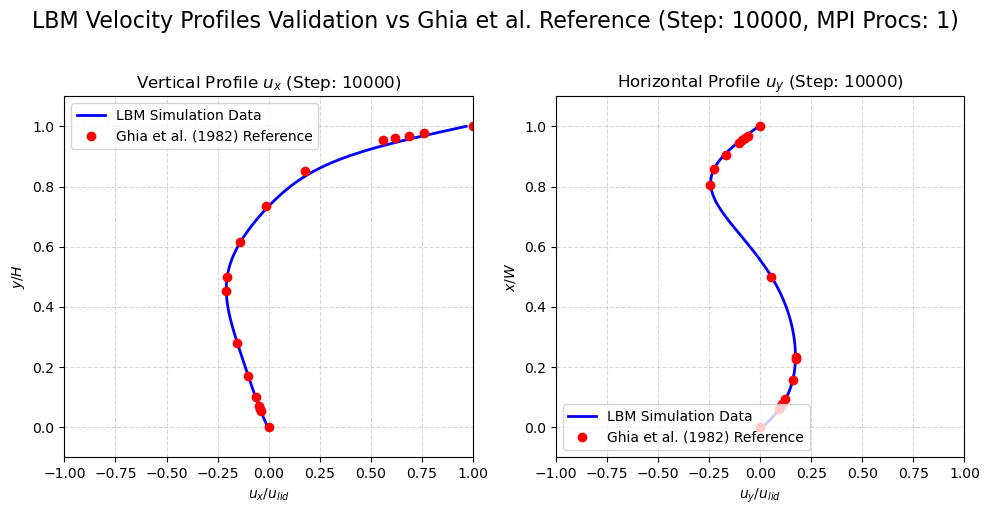

In [39]:
validate(suffix="_mpi_1_halo_off")

### 1.2 Decomposition without HALO

Loading data from: ../outputs/output_10000_mpi_2_halo_off.csv (Step: 10000)


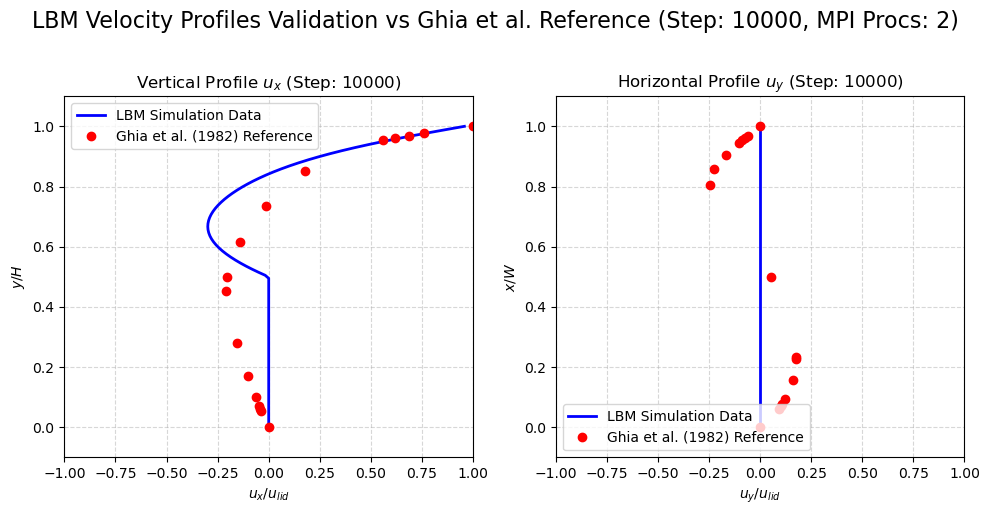

In [40]:
validate(suffix="_mpi_2_halo_off")

Loading data from: ../outputs/output_10000_mpi_4_halo_off.csv (Step: 10000)


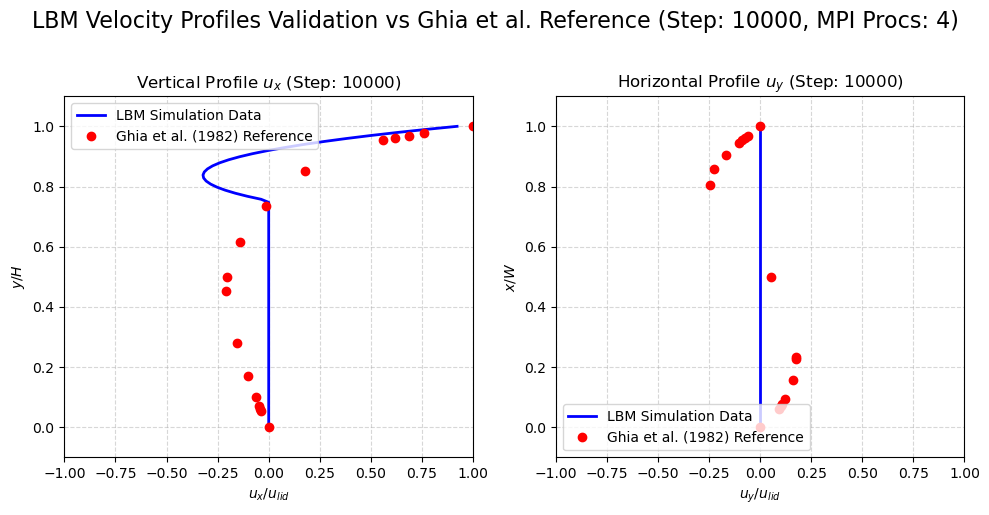

In [41]:
validate(suffix="_mpi_4_halo_off")

### 1.3 Decomposition with HALO

Loading data from: ../outputs/output_10000_mpi_2_halo_on.csv (Step: 10000)


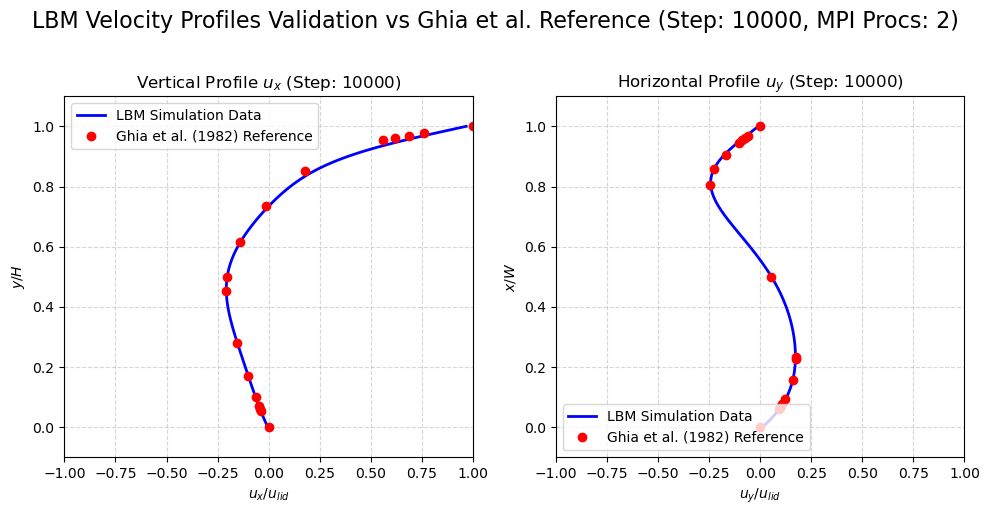

In [42]:
validate(suffix="_mpi_2_halo_on")

Loading data from: ../outputs/output_10000_mpi_4_halo_on.csv (Step: 10000)


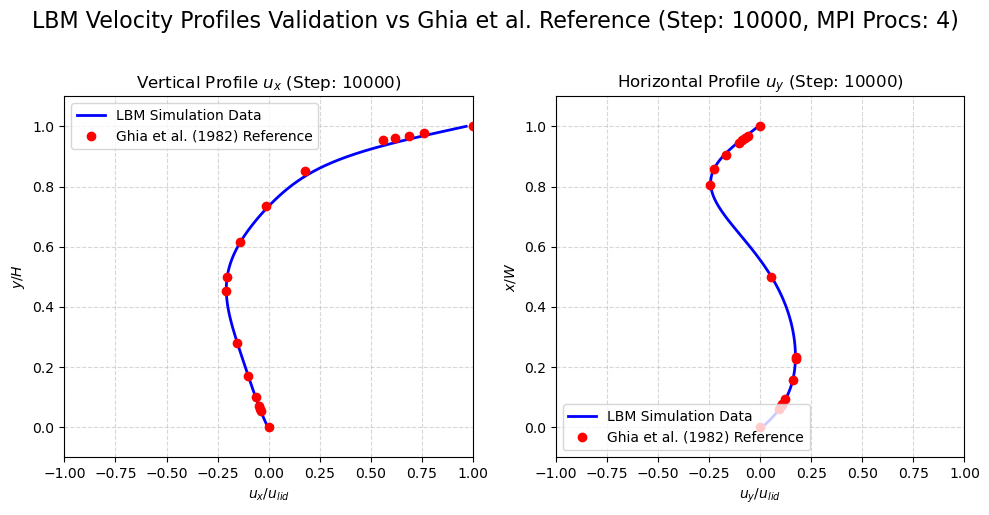

In [43]:
validate(suffix="_mpi_4_halo_on")

## 2. Parallel Verification: Spatial Node-by-Node Identity Check

In [44]:
def plot_parallel_verification_errors(step=10000, par_suffix=""):
    """
    Loads sequential and parallel simulation data, computes node-by-node absolute errors for 
    velocity components and their magnitude, and visualizes all three.
    """
    seq_file = f"../outputs/output_{step}.csv"
    par_file = f"../outputs/output_{step}{par_suffix}.csv"

    if not seq_file or not par_file:
        print("Error: Missing required CSV files for error mapping.")
        return

    if not os.path.exists(seq_file):
        print(f"Error: Sequential file missing")
        return
    if not os.path.exists(par_file):
        print(f"Error: Parallel file missing")
        return
    
    print(f"Comparing: {seq_file} VS {par_file}")

    df_seq = pd.read_csv(seq_file)
    df_par = pd.read_csv(par_file)

    # Reconstruct flat CSV rows into 2D grid shapes (H x W)
    ux_seq = df_seq.pivot(index='y', columns='x', values='ux').to_numpy()
    uy_seq = df_seq.pivot(index='y', columns='x', values='uy').to_numpy()
    ux_par = df_par.pivot(index='y', columns='x', values='ux').to_numpy()
    uy_par = df_par.pivot(index='y', columns='x', values='uy').to_numpy()

    # Calculate velocity magnitude: |U| = sqrt(ux^2 + uy^2)
    u_mag_seq = np.sqrt(ux_seq**2 + uy_seq**2)
    u_mag_par = np.sqrt(ux_par**2 + uy_par**2)

    # Calculate absolute error maps (|Sequential - Parallel|)
    diff_ux = np.abs(ux_seq - ux_par)
    diff_uy = np.abs(uy_seq - uy_par)
    diff_umag = np.abs(u_mag_seq - u_mag_par)

    # Pack structures for the 3-channel iterative plotting loop
    channels = ['Streamwise Velocity ($u_x$)', 'Transverse Velocity ($u_y$)', 'Velocity Magnitude ($|U|$)']
    seq_data = [ux_seq, uy_seq, u_mag_seq]
    par_data = [ux_par, uy_par, u_mag_par]
    diff_data = [diff_ux, diff_uy, diff_umag]
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))

    for i in range(3):
        im1 = axes[i, 0].imshow(seq_data[i], cmap='jet', origin='lower')
        axes[i, 0].set_title(f"Sequential: {channels[i]}")
        axes[i, 0].set_xlabel("x / W")
        axes[i, 0].set_ylabel("y / H")
        fig.colorbar(im1, ax=axes[i, 0], label="$u / u_{lid}$", shrink=0.7)

        im2 = axes[i, 1].imshow(par_data[i], cmap='jet', origin='lower')
        axes[i, 1].set_title(f"MPI Parallel: {channels[i]}")
        axes[i, 1].set_xlabel("x / W")
        axes[i, 1].set_ylabel("y / H")
        fig.colorbar(im2, ax=axes[i, 1], label="$u / u_{lid}$", shrink=0.7)

        im3 = axes[i, 2].imshow(diff_data[i], cmap='inferno', origin='lower')
        axes[i, 2].set_title(f"Absolute Error: {channels[i]}")
        axes[i, 2].set_xlabel("x / W")
        axes[i, 2].set_ylabel("y / H")
        fig.colorbar(im3, ax=axes[i, 2], label="Absolute Diff", shrink=0.7)

    match = re.search(r"_mpi_(\d+)", par_file) # MPI process count extraction
    if match:
        num_procs = match.group(1)
    else:
        num_procs = "1 (Sequential)"
        
    plt.suptitle(f"Parallel Execution Verification & Error Analysis (Step: {step}, MPI Procs: {num_procs})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 2.1 Sequential

Comparing: ../outputs/output_10000.csv VS ../outputs/output_10000_mpi_1_halo_off.csv


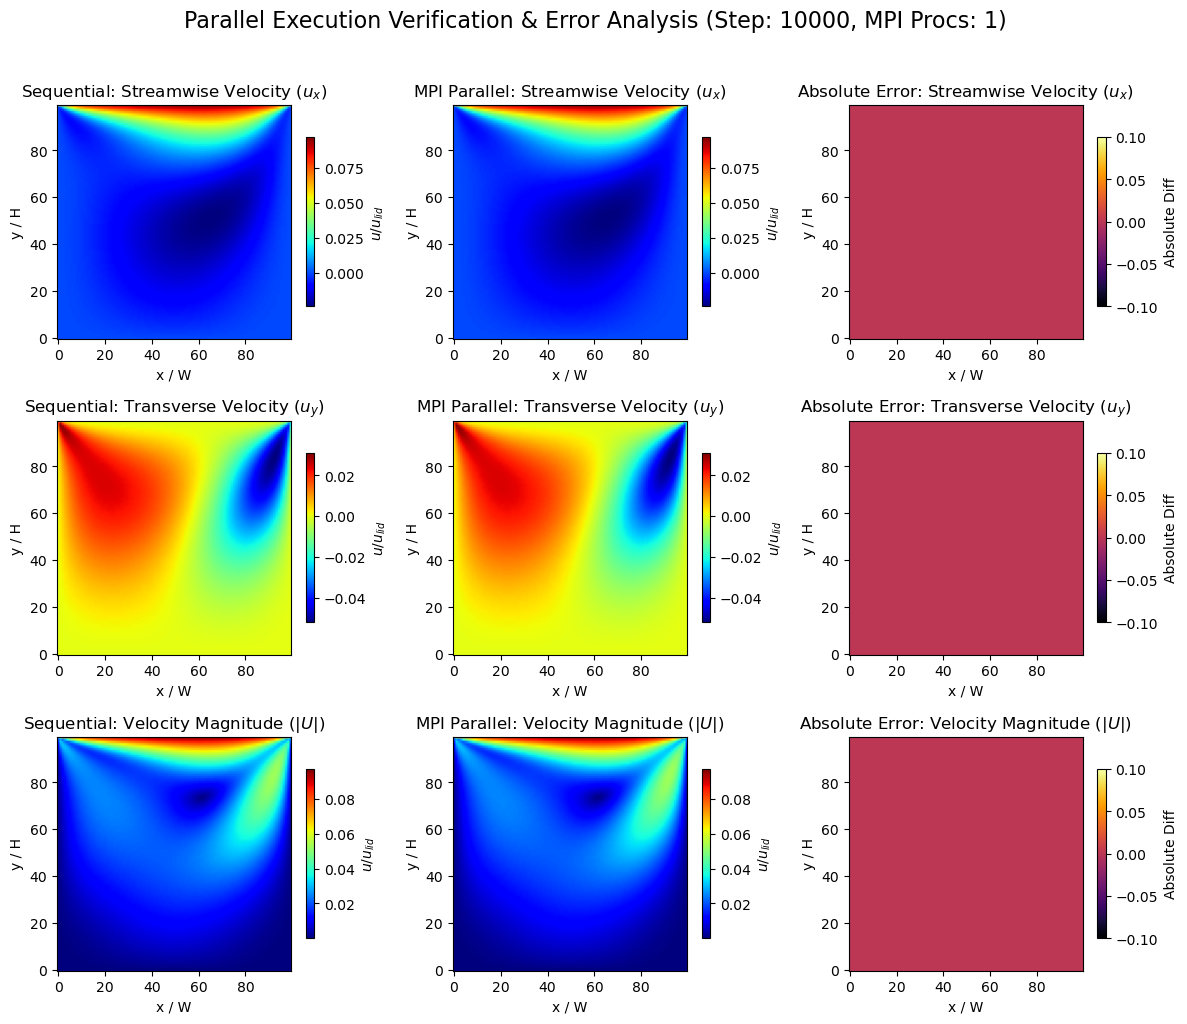

In [45]:
plot_parallel_verification_errors(step=10000, par_suffix="_mpi_1_halo_off")

### 2.2 Decomposition WITHOUT HALO: We treat MPI boundaries as physical walls

Comparing: ../outputs/output_10000.csv VS ../outputs/output_10000_mpi_2_halo_off.csv


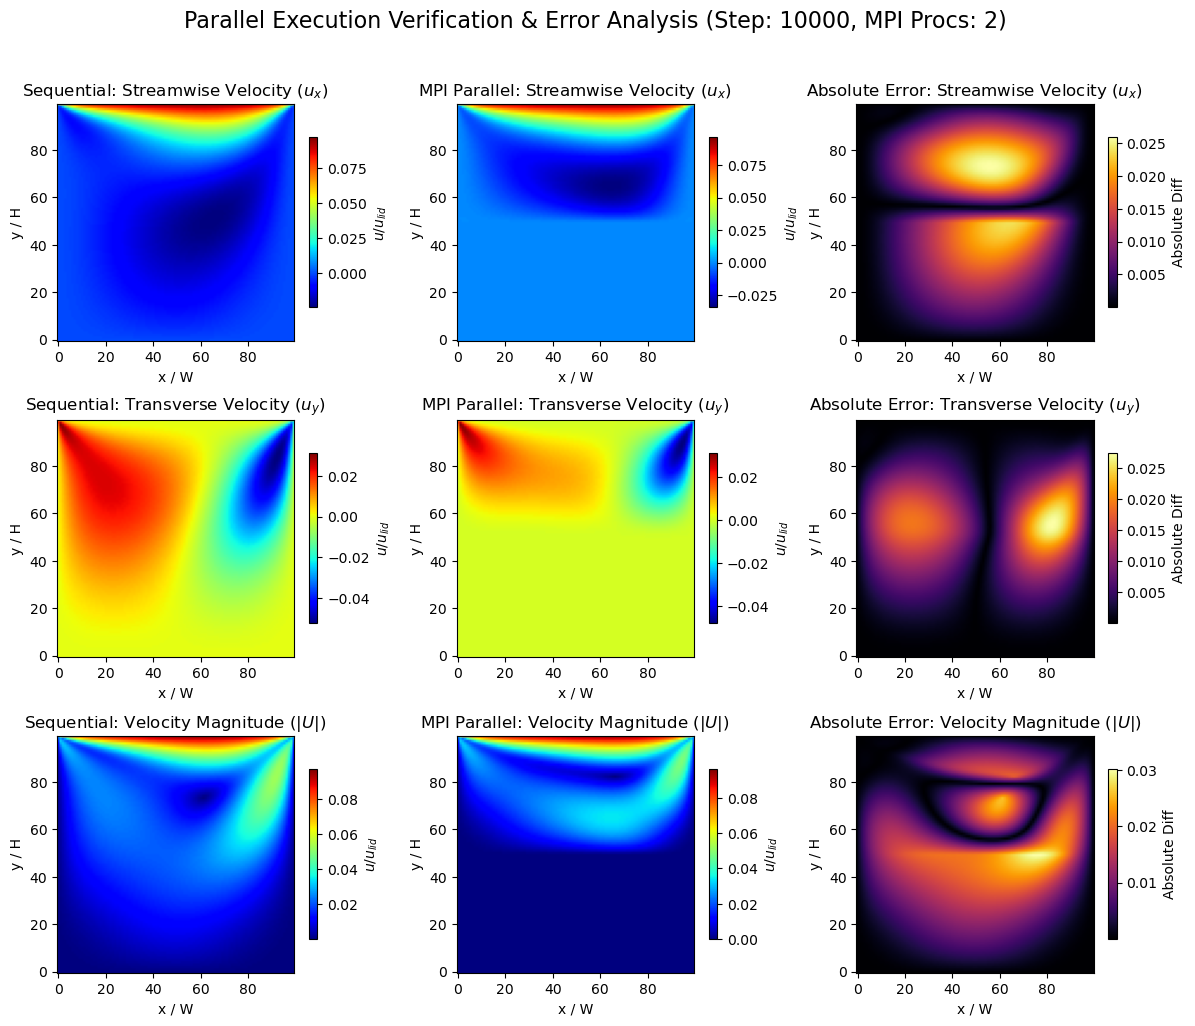

In [46]:
plot_parallel_verification_errors(step=10000, par_suffix="_mpi_2_halo_off")

Comparing: ../outputs/output_10000.csv VS ../outputs/output_10000_mpi_4_halo_off.csv


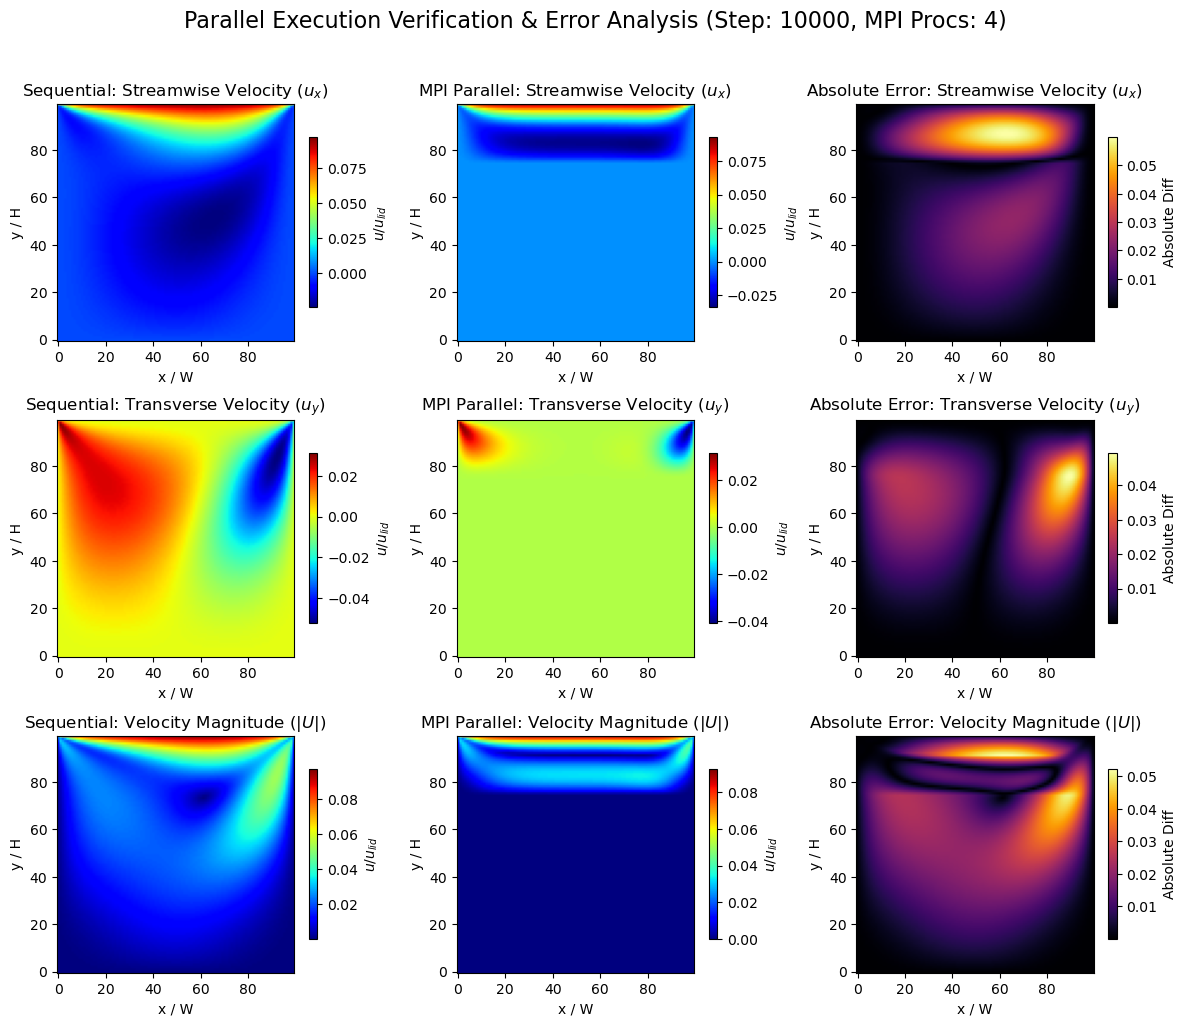

In [47]:
plot_parallel_verification_errors(step=10000, par_suffix="_mpi_4_halo_off")

### 2.3 Decomposition WITH HALO

Comparing: ../outputs/output_10000.csv VS ../outputs/output_10000_mpi_2_halo_on.csv


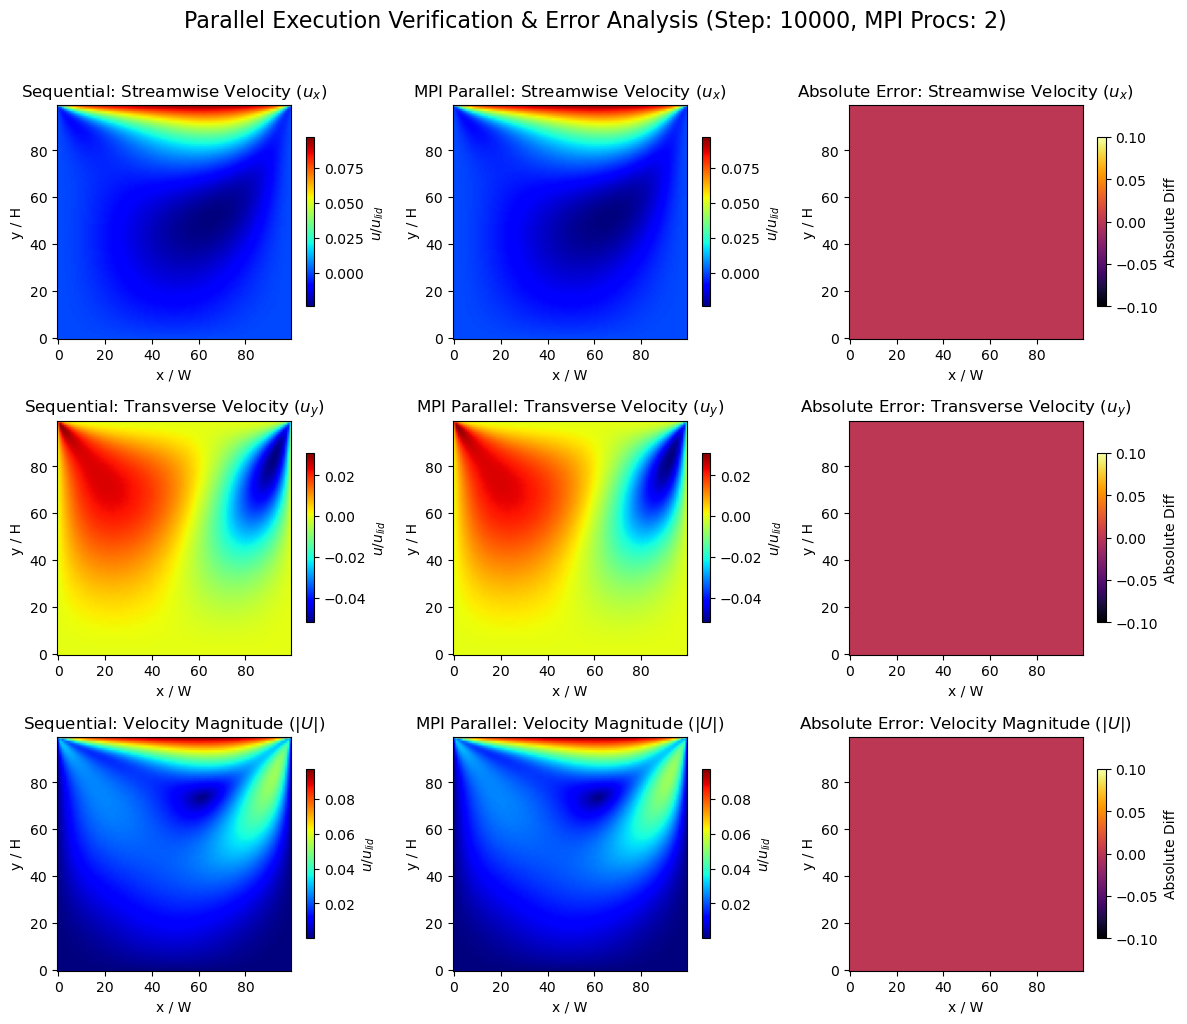

In [48]:
plot_parallel_verification_errors(step=10000, par_suffix="_mpi_2_halo_on")

Comparing: ../outputs/output_10000.csv VS ../outputs/output_10000_mpi_4_halo_on.csv


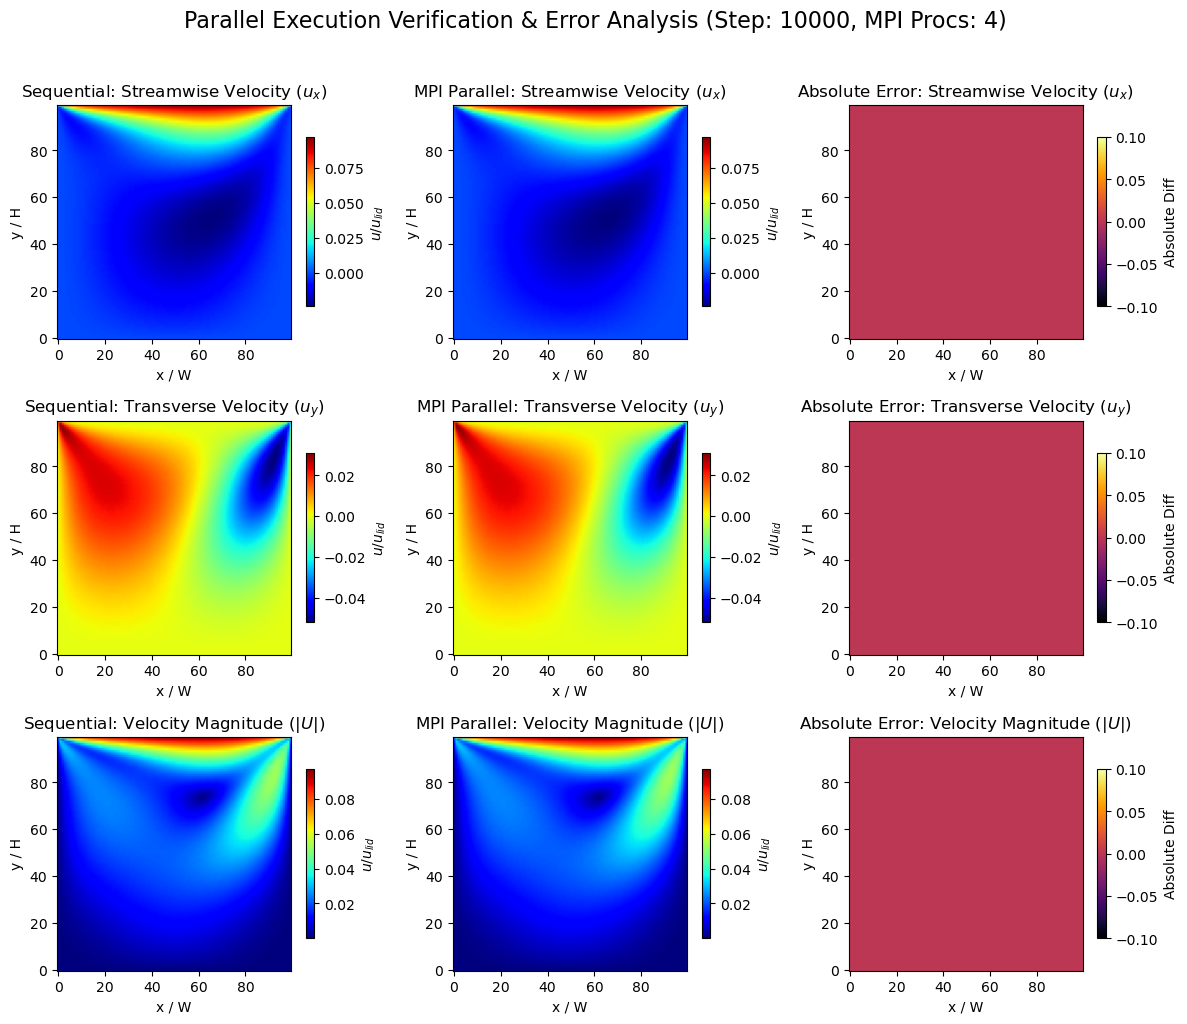

In [49]:
plot_parallel_verification_errors(step=10000, par_suffix="_mpi_4_halo_on")